# 1. Feature Engineering 

## 1.1 Feature Transformation

Feature engineering is the process of using domain knowledge and data analysis to transform raw data into meaningful inputs that help machine learning models learn patterns and make accurate predictions.  

**Handling Missing Data**  
**Encoding Categorical Variables:** Used when data contains text or category names (such as "red" or "blue") that algorithms cannot read directly. It converts words into numbers using methods like one-hot encoding.  

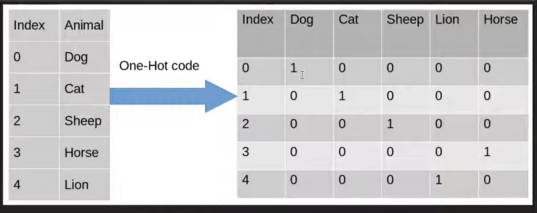      
**Scaling Numerical Data:** Used when numbers have widely different ranges.    
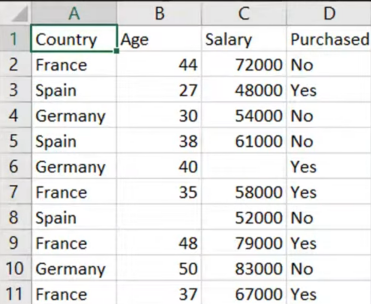
For plotting between Age and Salary,scaling is needed.  
**Managing Outliers:** Used when extreme or stray values skew data trends and reduce model accuracy.    
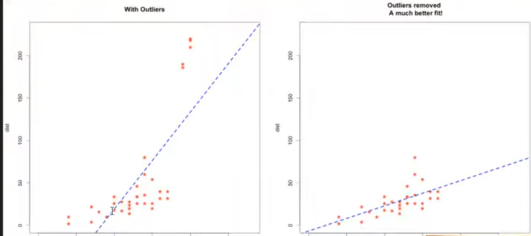

## 1.2 Feature Construction
Feature Construction (Creating New Variables)Feature construction is the process of manually building entirely new features from existing raw data using domain knowledge. You do this to help the model catch hidden relationships it cannot figure out on its own.  
You use math operations, logic, or business rules to merge multiple columns.  
**Eg -** Combine column number of siblings,parents, spouse into total family members 

## 1.3 Feature Selection (Filtering Existing Variables)
Feature selection is the process of picking a specific subset of your original features and throwing away irrelevant, noisy, or redundant data.Goal: Keep the data clean, reduce model training times, and prevent overfitting.  
It evaluates features using statistical tests (like correlation) or model performance weights to keep the best ones, without altering the original meaning of those columns.

## 1.4 Feature Extraction (Transforming and Compressing Variables)
Feature extraction is the process of projecting a high-dimensional dataset into a brand new, lower-dimensional space. Instead of picking some columns and deleting others, it mathematically blends all columns into a smaller set of completely new variables.Goal: Drastically reduce data complexity (dimensionality reduction) while retaining the core patterns.  
It runs complex algebraic equations like Principal Component Analysis (PCA) to crunch 100 features down into 5 compressed columns.

## 1.1 Feature Scaling
Standardize independent features in a fixed range.  

### 1.1.1 Standardization (Z-Score Normalization)  
Scales features to have a mean of 0 and a standard deviation of 1.


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df=pd.read_csv('Social_Network_Ads.csv')
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

### Train Test Split

In [35]:
from sklearn.model_selection import train_test_split as tt
X_train,X_test,Y_train,Y_test=tt(df.drop('Purchased', axis=1),
                                df['Purchased'],
                                test_size=0.3,
                                random_state=0)
X_train.shape, X_test.shape

((280, 4), (120, 4))

### Standard Scaler

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to train set, it eill learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
scaler.mean_

array([1.56917817e+07, 3.78642857e+01, 6.98071429e+04, 5.03571429e-01])

In [38]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [39]:
np.round(X_train.describe(), 1)

,User ID,Age,EstimatedSalary
count,280.0,280.0,280.0
mean,15691781.7,37.9,69807.1
std,70759.6,10.2,34641.2
min,15569641.0,18.0,15000.0
25%,15628197.2,30.0,43000.0
50%,15694424.0,37.0,70500.0
75%,15751110.8,46.0,88000.0
max,15814816.0,60.0,150000.0


In [40]:
plt.show()

### Effect of Scaling

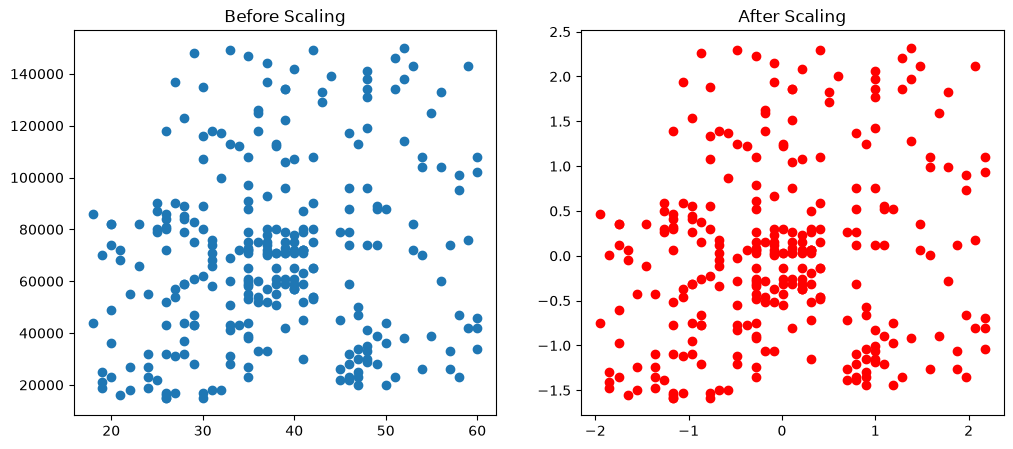

In [41]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize = (12,5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='red')
ax2.set_title("After Scaling")
plt.show()

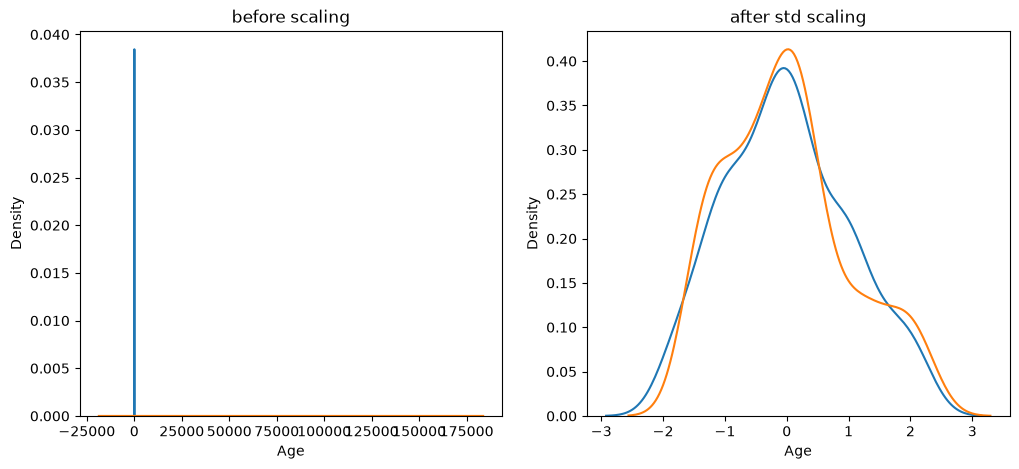

In [42]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize = (12,5))

ax1.set_title("before scaling")
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

ax2.set_title("after std scaling")
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

### Comparison of distrubutions

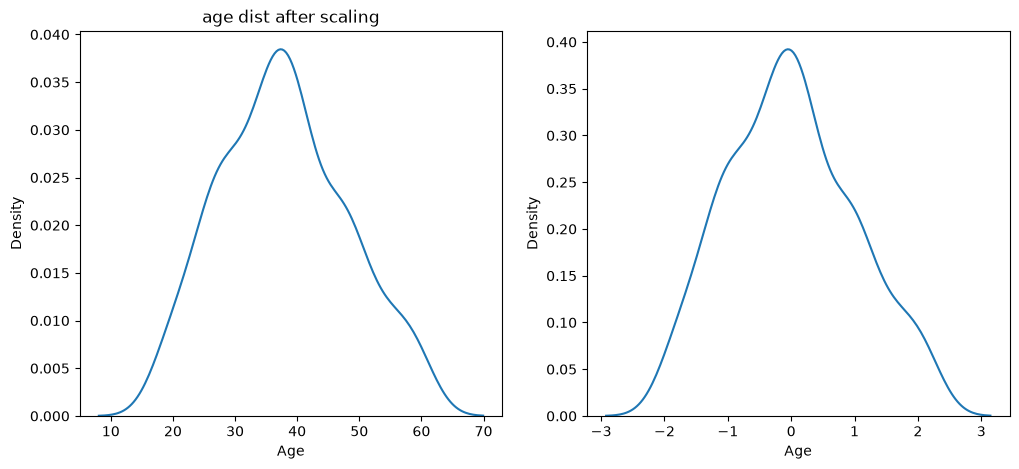

In [43]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize = (12,5))

ax1.set_title('age dist before scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

ax1.set_title('age dist after scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
plt.show()

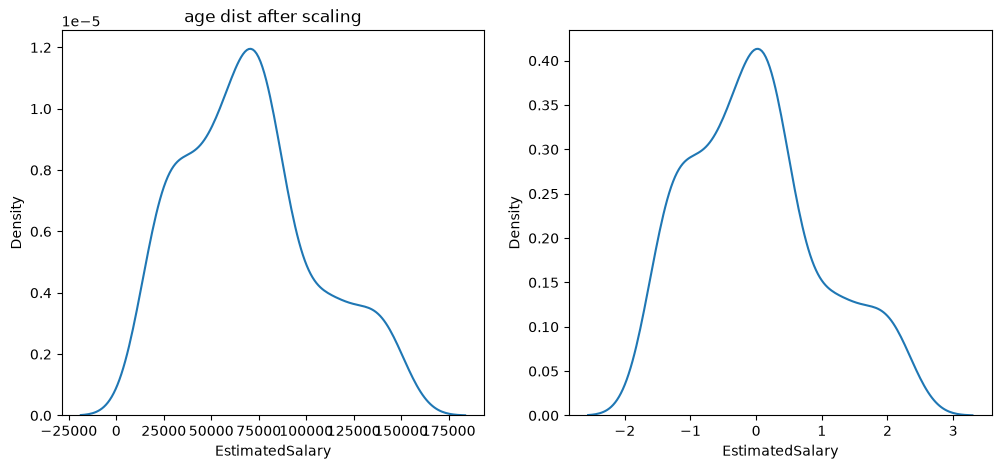

In [44]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize = (12,5))

ax1.set_title('age dist before scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

ax1.set_title('age dist after scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

### Why Scaling is Important?

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [47]:
lr.fit(X_train, Y_train)
lr_scaled.fit(X_train_scaled, Y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [48]:
Y_pred=lr.predict(X_test)
Y_pred_scaled=lr_scaled.predict(X_test_scaled)

In [49]:
from sklearn.metrics import accuracy_score

In [50]:
print("Actual",accuracy_score(Y_test,Y_pred))
print("Scaled",accuracy_score(Y_test,Y_pred_scaled))

Actual 0.8666666666666667
Scaled 0.8833333333333333


In [51]:
from sklearn.tree import DecisionTreeClassifier

In [52]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [53]:
dt.fit(X_train,Y_train)
dt_scaled.fit(X_train_scaled,Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [54]:
Y_pred = dt.predict(X_test)
Y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [56]:
print("Actual",accuracy_score(Y_test,Y_pred))
print("Scaled",accuracy_score(Y_test,Y_pred_scaled))

Actual 0.8916666666666667
Scaled 0.875


In [57]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


### 1.1.2 Normalization
Goal is to change the values of numeric columns in the dataset to use a common scale, without distorting differences in the ranges of values or losing information.  
**Min-max Scaling, Mean Normalization, Max absolute, Robust Scaling**

### a. Minmax Scaling - Intuition
Min-Max scaling maps each feature to [0, 1] by subtracting the feature minimum and dividing by the range: (x - x_min) / (x_max - x_min). It preserves the relative ordering and zero values while eliminating magnitude differences between features.

### b. Mean Normalization
In Machine Learning, mean normalization is a feature scaling technique where each feature value is adjusted so that the feature has a mean of 0.

The formula for mean normalization is: x'=(x-$x_{mean}$)/($x_{max}$ - $x_{min}$  )  

### c. MaxAbs Scaling
MaxAbs Scaling scales each feature by its maximum absolute value. The output values fall within the range [−1, 1]. If the data contains only positive numbers, it is equivalent to Min-Max Scaling (scaled to [0, 1]).
$x_{new}$=$x_{i}$/|$x_{max}$|

### d. Robust Scaling
Robust Scaling in Machine Learning is a feature scaling technique that uses the median and interquartile range (IQR) instead of the mean and standard deviation.
This makes it less sensitive to outliers compared to StandardScaler.


Formula - x'= x-Median(X)/IQR(X)
Where:
Median(x)=median of the feature values
IQR(X)=$Q_{3}$-$Q_{1}  
 $Q_{1}$=25th percentile, $Q_{3}$ =75th percentile


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv('wine.csv', header=None, usecols=[0,1,2])
df.columns=['Class label', 'Alcohol', 'Malic Acid']
df=df.drop(index=0)
df['Alcohol']=df['Alcohol'].astype(float)
df['Malic Acid']=df['Malic Acid'].astype(float)
df['Class label']=df['Class label'].astype(float)
df

,Class label,Alcohol,Malic Acid
1,1.0,14.23,1.71
2,1.0,13.20,1.78
3,1.0,13.16,2.36
4,1.0,14.37,1.95
5,1.0,13.24,2.59
...,...,...,...
174,3.0,13.71,5.65
175,3.0,13.40,3.91
176,3.0,13.27,4.28
177,3.0,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

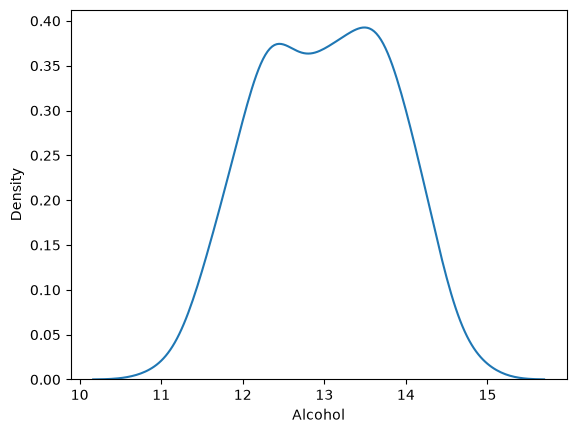

In [29]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

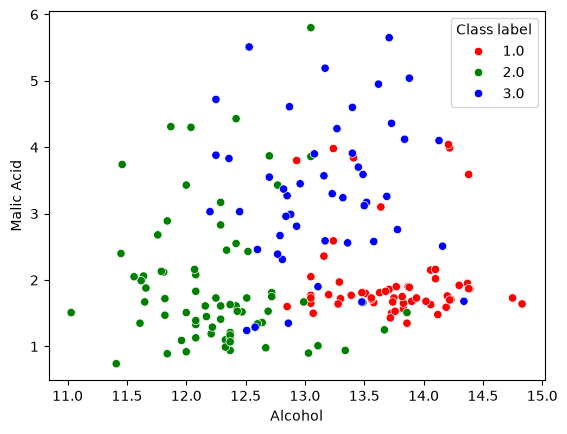

In [30]:
color_dist={1:'red', 2:'green', 3:'blue'}
sns.scatterplot(x=df['Alcohol'], y=df['Malic Acid'], hue=df['Class label'], palette=color_dist)

In [31]:
from sklearn.model_selection import train_test_split as tt
X_train,X_test,y_train,y_test=tt(df.drop('Class label', axis=1),
                                df['Class label'],
                                test_size=0.3,
                                random_state=0)
X_train.shape, X_test.shape

((124, 2), (54, 2))

In [37]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(X_train)   #fit scaler to train set,it will learn the parameters
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_train_scaled=pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [38]:
np.round(X_train.describe(),1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


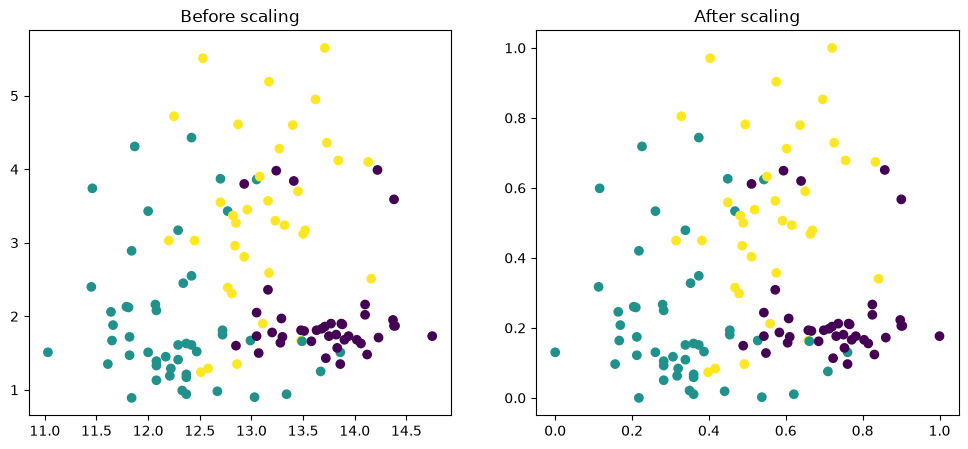

In [40]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(X_train['Alcohol'], X_train['Malic Acid'], c=y_train)
ax1.set_title("Before scaling")

ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic Acid'], c=y_train)
ax2.set_title("After scaling")
plt.show()

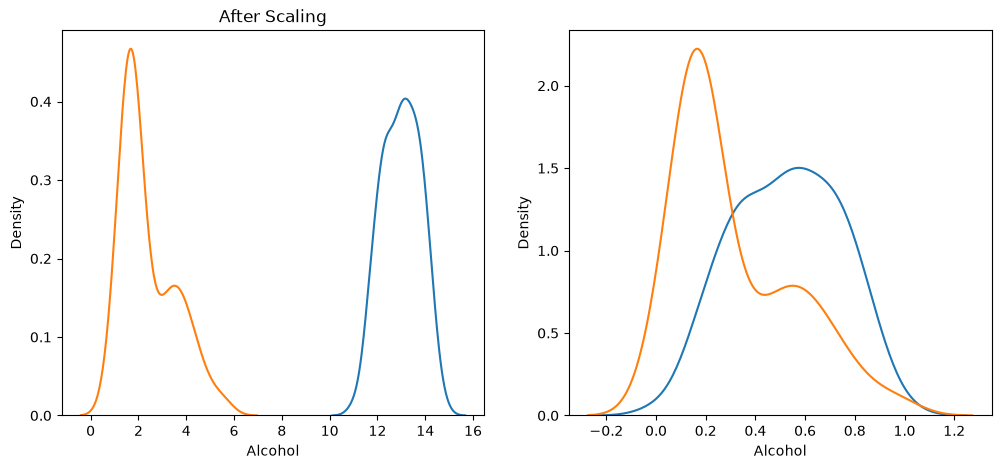

In [42]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title("Before Scaling")
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic Acid'], ax=ax1)

ax1.set_title("After Scaling")
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic Acid'], ax=ax2)
plt.show()

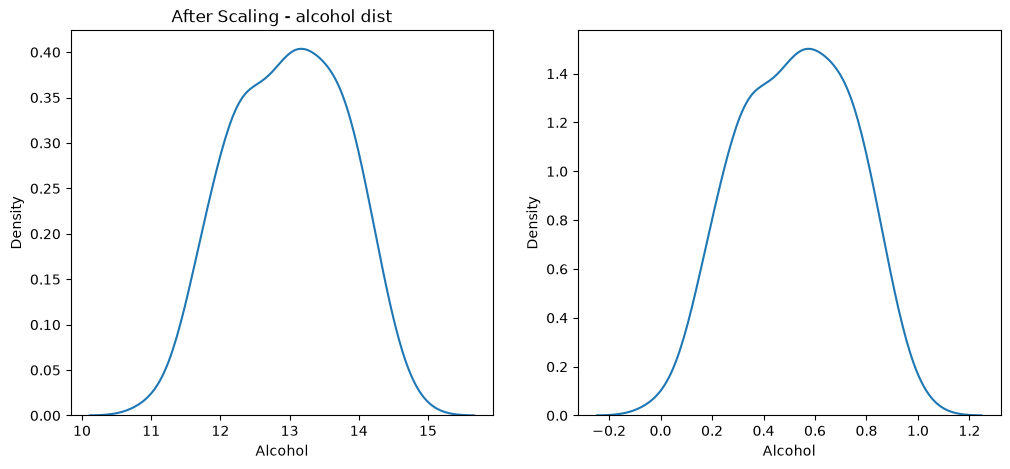

In [43]:
ig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title("Before Scaling- alcohot dist")
sns.kdeplot(X_train['Alcohol'], ax=ax1)

ax1.set_title("After Scaling - alcohol dist")
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

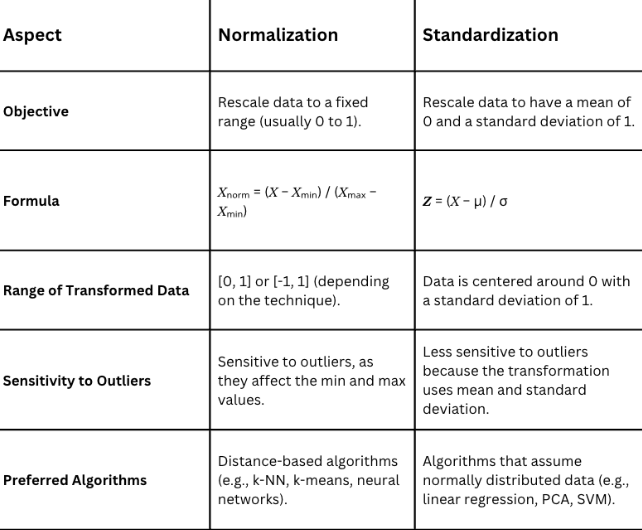